<a href="https://colab.research.google.com/github/Akanshajoshiiii/SpeechLAB/blob/main/Copy_of_UCS749_Lab2_Signal_representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating a synthetic signal and representing in time domain

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def get_signal_Hz(Hz,sample_rate,length_ts_sec):
    ## 1sec length time series with sampling rate
    ts1sec = list(np.linspace(0,np.pi*2*Hz,sample_rate))
    ts = ts1sec*length_ts_sec
    return(list(np.sin(ts)))

sample_rate   = 4000
length_ts_sec = 3
## --------------------------------- ##
## 3 seconds of "digit 1" sound
## Pressing digit 2 buttom generates
## the sine waves at frequency
## 697Hz and 1209Hz.
## --------------------------------- ##
ts1  = np.array(get_signal_Hz(697, sample_rate,length_ts_sec))
ts1 += np.array(get_signal_Hz(1209,sample_rate,length_ts_sec))
ts1  = list(ts1)

## -------------------- ##
## 2 seconds of silence
## -------------------- ##
ts_silence = [0]*sample_rate*1

## --------------------------------- ##
## 3 seconds of "digit 2" sounds
## Pressing digit 2 buttom generates
## the sine waves at frequency
## 697Hz and 1336Hz.
## --------------------------------- ##
ts2  = np.array(get_signal_Hz(697, sample_rate,length_ts_sec))
ts2 += np.array(get_signal_Hz(1336,sample_rate,length_ts_sec))
ts2  = list(ts2)

## -------------------- ##
## Add up to 7 seconds
## ------------------- ##
ts = ts1 + ts_silence  + ts2

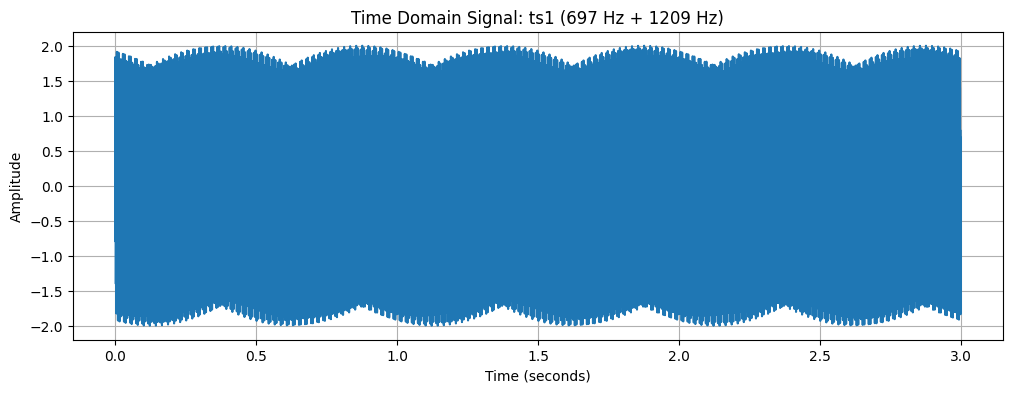

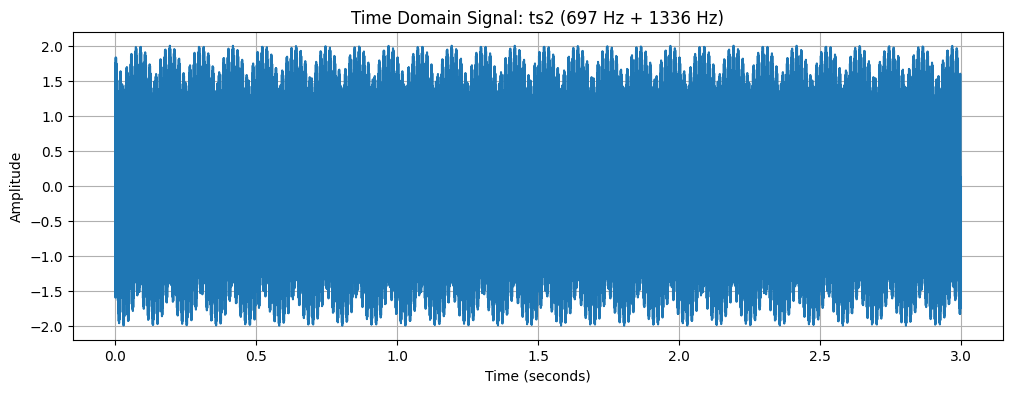

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert lists to numpy arrays (safe practice)
ts1 = np.array(ts1)
ts2 = np.array(ts2)

# Create time axis (in seconds)
t = np.arange(len(ts1)) / sample_rate

# Plot time-domain signal for ts1
plt.figure(figsize=(12, 4))
plt.plot(t, ts1)
plt.title("Time Domain Signal: ts1 (697 Hz + 1209 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Plot time-domain signal for ts2
plt.figure(figsize=(12, 4))
plt.plot(t, ts2)
plt.title("Time Domain Signal: ts2 (697 Hz + 1336 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [ ]:
from IPython.display import Audio
audio=Audio(ts, rate=sample_rate)
audio

Representing the signal in Frequency domain

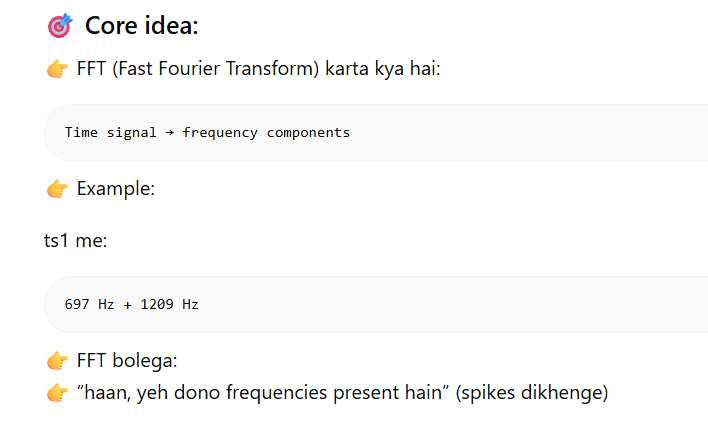

👉 Ensure signal array format me ho  

👉 FFT numpy arrays pe best kaam karta hai    
**freqs = np.fft.fftfreq(N, d=1/fs)**

👉 Yeh batata hai:  

👉 “FFT ke output me kaunsa index kaunsi frequency ko represent karta hai”  

Breakdown:
N → number of points
d = 1/fs → time gap between samples

👉 Output:

[0, 1, 2, ..., fs/2, ..., -1]

👉 Matlab:

positive + negative frequencies


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays
ts1 = np.array(ts1)
ts2 = np.array(ts2)

N = len(ts1)                  # Number of samples
fs = sample_rate              # Sampling frequency

# Frequency axis
freqs = np.fft.fftfreq(N, d=1/fs)

# FFT computation
fft_ts1 = np.fft.fft(ts1)
fft_ts2 = np.fft.fft(ts2)


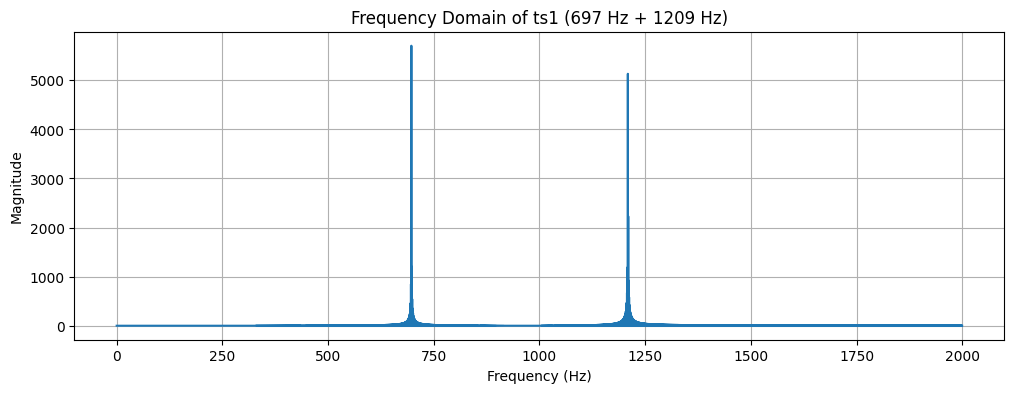

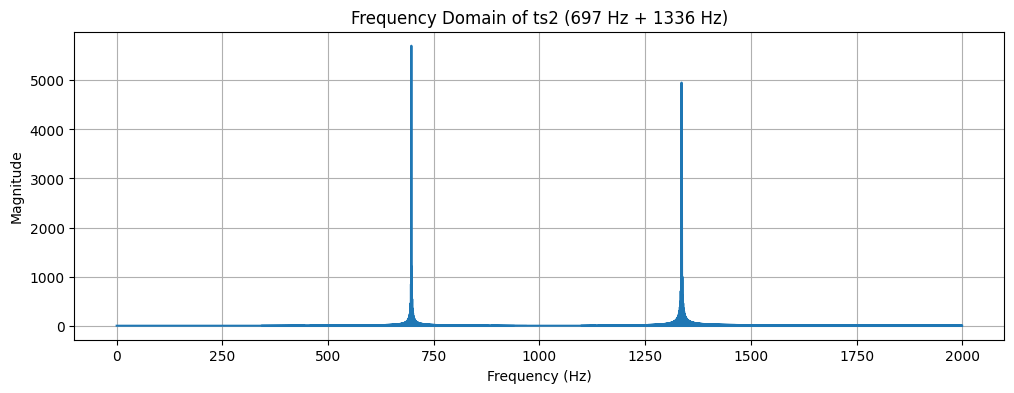

In [ ]:
# Take only positive frequencies
half_N = N // 2

plt.figure(figsize=(12, 4))
plt.plot(freqs[:half_N], np.abs(fft_ts1[:half_N]))
plt.title("Frequency Domain of ts1 (697 Hz + 1209 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(freqs[:half_N], np.abs(fft_ts2[:half_N]))
plt.title("Frequency Domain of ts2 (697 Hz + 1336 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


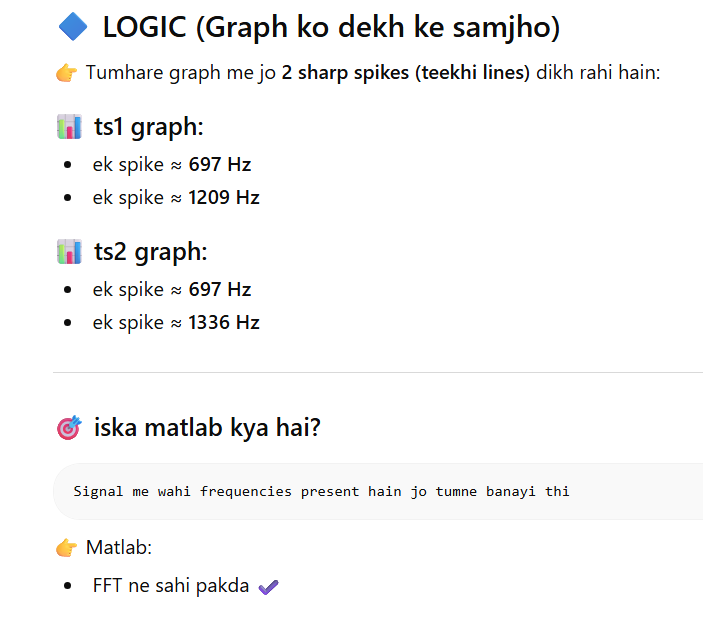


Spectrograms are visual representations of audio – representing time, frequency, and amplitude all on one graph. A spectrogram is a time–frequency representation of a signal that shows how the frequency content of the signal changes over time.
In simple terms:
Time → shown on the horizontal axis
Frequency → shown on the vertical axis
Amplitude / Energy → shown using color or intensity.
They visually reveal audio problems by sight, like broadband, electrical, or intermittent noise, which can help us make decisions with mixing music or editing sound.


plt.specgram():
Splits the signal into short overlapping segments
Applies a window to each segment
Computes the FFT of every segment
Converts magnitude to power
Displays the result as a time–frequency heatmap
Mathematically, it performs the Short-Time Fourier Transform (STFT) and plots:
Spectrogram(t,f)=∣STFT(t,f)∣^2

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:8233: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


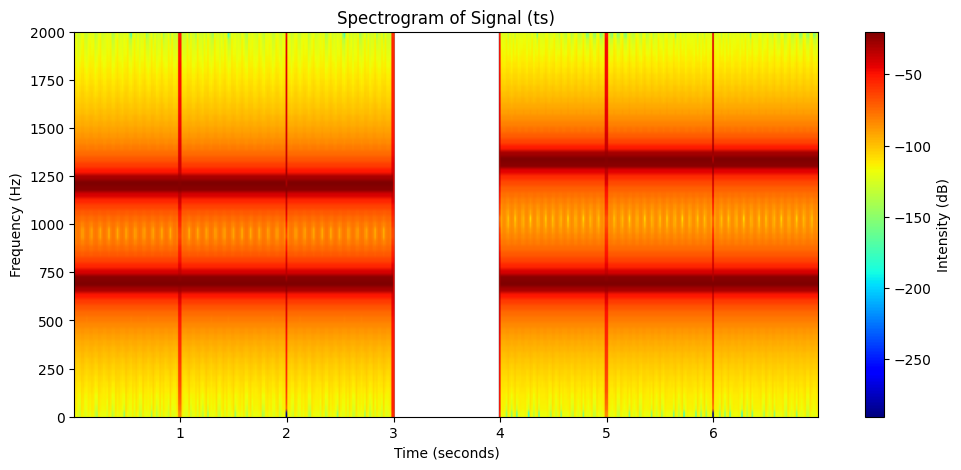

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert full signal to numpy array
ts = np.array(ts)
fs = sample_rate
plt.figure(figsize=(12, 5))

plt.specgram(
    ts,
    NFFT=128,        # Wind size #ek time pe 128 samples ka chunk liya
    Fs=fs,            # Sampling frequency
    noverlap=64,     # Overlap between windowsNumber of samples shared between adjacent frames
    cmap="jet"
)

#small window → better time detail
#large window → better frequency detail
plt.title("Spectrogram of Signal (ts)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Intensity (dB)")
plt.show()


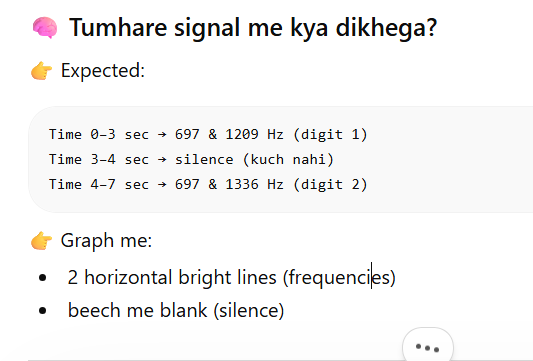

Spectrogram using Scipy
| Color     | Meaning          |
| --------- | ---------------- |
| Dark blue | Very low energy  |
| Green     | Medium energy    |
| Yellow    | High energy      |
| Red       | Very high energy |


In [ ]:
import numpy as np
from scipy import signal
from scipy.fft import fftshift
import matplotlib.pyplot as plt

Sxx

👉 intensity matrix

👉 size:

(frequencies × time)

👉 matlab:

Sxx[i][j] = frequency f[i] at time t[j] ki strength

**Important Understanding**

👉 Yeh pura process actually hai:

STFT = Short Time Fourier Transform

👉 Matlab:

har small time window pe FFT lagana

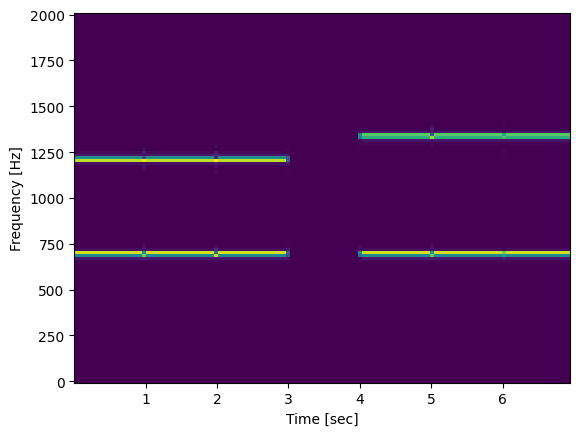

In [ ]:
#computing STFT i.e. fourier transforms in regular intervals
#ts → full signal
#4000 → sampling rate (fs)

f, t, Sxx = signal.spectrogram(np.array(ts), 4000)
plt.pcolormesh(t, f, Sxx)
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

🔷 Ab graph me kya dikh raha hai
🔹 0 to 3 sec (left side)

👉 2 bright horizontal lines:

~700 Hz
~1200 Hz

👉 Matlab:

Digit 1 tone (697 + 1209 Hz)

✔️ Exactly wahi jo tumne generate kiya

🔹 3 to 4 sec (middle)

👉 Blank area (dark)

👉 Matlab:

Silence (no frequency)

✔️ Perfect

🔹 4 to 7 sec (right side)

👉 Again 2 lines:

~700 Hz
~1350 Hz

👉 Matlab:

Digit 2 tone (697 + 1336 Hz)

Spectrogram using Librosa

| Color                 | Interpretation                               |
| --------------------- | -------------------------------------------- |
| Dark purple / black   | Very low energy (silence / background noise) |
| Dark blue             | Low energy                                   |
| Green                 | Medium energy                                |
| Yellow/Orange                | High energy                                  |
| White / bright yellow | Very high energy                             |




In [ ]:
import librosa #audio processing library
import librosa.display #spectogram plot
import IPython.display as ipd

In [ ]:
audio_data=np.array(ts)

In [ ]:
stft_audio = librosa.stft(audio_data, n_fft = 128, hop_length = 64)
#n_fft=length of the windowed signal
#hop_length= number of samples between two successive frames

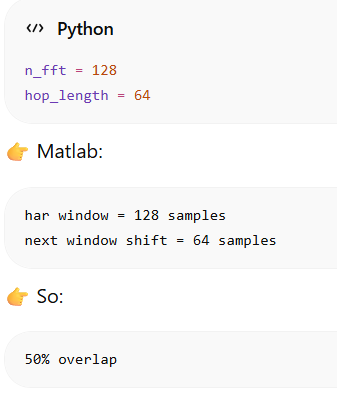

/tmp/ipython-input-4182499670.py:1: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(stft_audio, sr = 4000, hop_length = 64, x_axis = "time", y_axis = "linear")


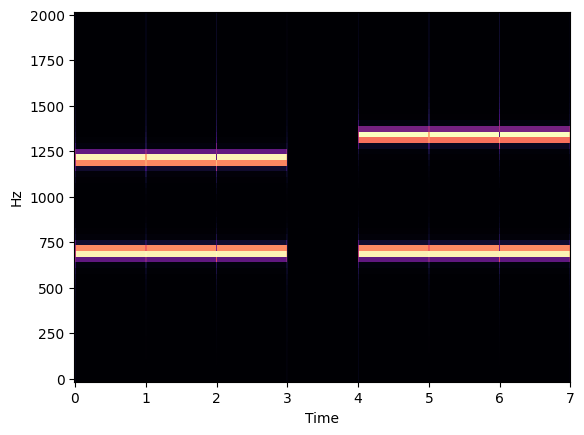

In [ ]:
librosa.display.specshow(stft_audio, sr = 4000, hop_length = 64, x_axis = "time", y_axis = "linear")

In [ ]:
#better version

S = np.abs(stft_audio)

librosa.display.specshow(
    S,
    sr=4000,
    hop_length=64,
    x_axis="time",
    y_axis="linear"
)

plt.colorbar()
plt.title("Librosa Spectrogram")
plt.show()

Assignment: Plot the spectrogram of a .wav file.*

In [ ]:
pip install librosa matplotlib numpy fastdtw scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567860 sha256=b3ce73bf6c3a44693b0f85572c022157cb7e4658312b63daaead5fc1d724939a
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw
